In [7]:
from time import time

import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
)
from hetero_isas.monodromy_lp.decomposer import MonodromyLPDecomposerResult
from hetero_isas.monodromy_lp.invariants import recover_local_equivalence
from hetero_isas.monodromy_lp.isa import ISAHandler
from hetero_isas.monodromy_lp.mono_lp_result import plot_histograms
from hetero_isas.zz_parallel_drive.ansatz import BasicCircuitAnsatz
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit import Gate, Parameter
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qiskit.synthesis.two_qubit.local_invariance import two_qubit_local_invariants
from qutip import Qobj
from tqdm.notebook import tqdm
from weylchamber import c1c2c3

generator = Philox(0)

%matplotlib inline

In [8]:
isa_handler = ISAHandler(
    [
        CXGate(),
        CXGate().power(1 / 2),
        CXGate().power(1 / 3),
        # CXGate().power(1 / 4),
        # CXGate().power(1 / 5),
    ],
    [
        1.0,
        1 / 2,
        1 / 3,
        # 1 / 4,
        # 1 / 5,
    ],
    [
        "cx,",
        "sq[2]cx",
        "sq[3]cx",
        # "sq[4]cx",
        # "sq[5]cx",
    ],
)

# isa_handler = ISAHandler(
#     [
#         iSwapGate(),
#         iSwapGate().power(1 / 2),
#         iSwapGate().power(1 / 3),
#     ][1:2],
#     [1.0, 1 / 2, 1 / 3][1:2],
#     ["is,", "sq[2]is", "sq[3]is"][1:2],
# )

scipy_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=True)
cplex_decomposer = MonodromyLPDecomposer(isa_handler, use_ordered_sequences=False)
decomposer = scipy_decomposer

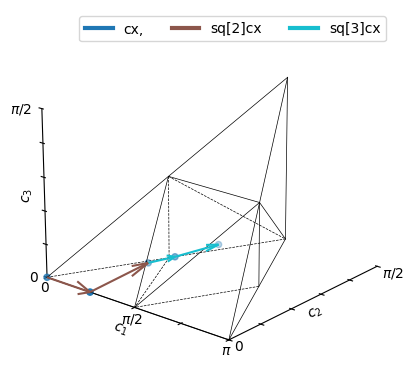

In [9]:
target_gate = SwapGate()
target_gate = random_unitary(4).to_matrix()
mono_result = decomposer._best_decomposition(target_gate)
mono_result.render_path();

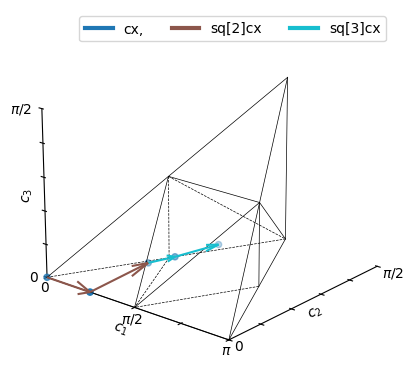

In [10]:
mono_result.render_path()
plt.savefig("example_traj.svg", bbox_inches="tight")

(np.float64(0.5), np.float64(0.49999997), np.float64(0.49999989))


Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 1.00000000e+00-1.77289546e-07j  1.66533454e-16-2.10942375e-15j
  -1.23517726e-09+3.20586028e-09j  4.13213879e-10+3.94999722e-08j]
 [ 1.23517742e-09+3.20586051e-09j -4.13199566e-10-4.16449333e-08j
   1.00000000e+00+1.77289545e-07j -2.77555756e-16+2.02615702e-15j]
 [ 6.66133815e-16-1.88737914e-15j  1.00000000e+00+1.77289547e-07j
   4.13214433e-10-4.16449338e-08j  1.23517979e-09-3.20586419e-09j]
 [-4.13200014e-10+3.94999718e-08j -1.23517946e-09-3.20586421e-09j
   2.77555756e-16+2.24820162e-15j  1.00000000e+00-1.77289548e-07j]]

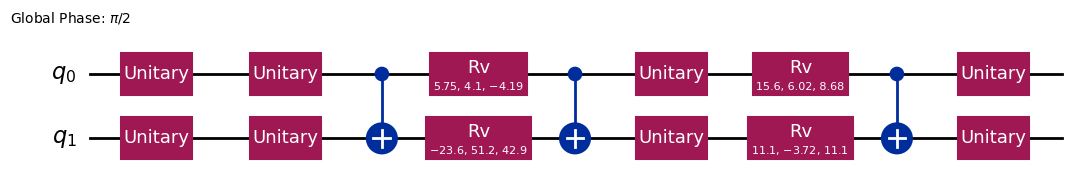

In [11]:
result = decomposer(SwapGate())
# result = decomposer(random_unitary(4).to_matrix())
result_u = Operator(result).data
print(c1c2c3(result_u))
display(Qobj(result_u))  # inspect for correctness
result.draw("mpl");

In [12]:
decomposer.numeric_decomposer.allow_fail = True
mono_durations = []
result_list = []
for _ in tqdm(range(N := 1_000)):
    time_start = time()
    target_gate = random_unitary(4).to_matrix()
    output_qc, lp_result = decomposer(target_gate, debugging=True)
    mono_durations.append(time() - time_start)
    result_list.append(lp_result)

  0%|          | 0/1000 [00:00<?, ?it/s]

/home/evm9/hetero_isas/src/hetero_isas/monodromy_lp/invariants.py:94: UserWarning: Tried to recover local equivalence, but the c parameter had a sign difference.
  warnings.warn(


Tried to recover local equivalence on gates that were not locally equivalent.                 Often this is a matter of precision. The difference between expected and given                 weyl coords was [6.76965290e-06 4.47947152e-03 1.04970473e-03]. If this is close to 0, then adjust tolerances.
Tried to recover local equivalence on gates that were not locally equivalent.                 Often this is a matter of precision. The difference between expected and given                 weyl coords was [6.53182436e-05 1.55849587e-03 1.60581032e-03]. If this is close to 0, then adjust tolerances.
Tried to recover local equivalence on gates that were not locally equivalent.                 Often this is a matter of precision. The difference between expected and given                 weyl coords was [0.00167797 0.02352698 0.02518364]. If this is close to 0, then adjust tolerances.
Tried to recover local equivalence on gates that were not locally equivalent.                 Often this is a ma

In [13]:
# cplex_decomposer.numeric_decomposer.allow_fail = True
# cplex_durations = []
# # cplex_result_list = []
# for _ in tqdm(range(N := 1_000)):
#     time_start = time()
#     target_gate = random_unitary(4).to_matrix()
#     output_qc, lp_result = cplex_decomposer(target_gate, debugging=True)
#     cplex_durations.append(time() - time_start)
#     # cplex_result_list.append(lp_result)

In [21]:
# print some things that we might care about :)
print(result_list[1])
print(np.mean([np.mean(result.total_nfev) for result in result_list]))
print(np.mean([result.lp_calls for result in result_list]))
print(np.mean([np.max(result.restarts) for result in result_list]))
print(np.max([np.max(result.restarts) for result in result_list]))
print(np.max([np.max(result.total_nfev) for result in result_list]))
print(np.mean([np.max(result.success_nfev) for result in result_list]))

MonodromyLPDecomposerResult:
            Number of segments: 4
            Gates strength: 0.4583
            LP calls: 2
            1Q numerics success: True
            1Q numerics restarts: [1, 1, 1]
            Total function evaluations: [256, 256, 256]
            Function evaluations on success: [256, 256, 256]
            ISA sequence: ['sq[2]cx', 'sq[2]cx', 'sq[2]cx', 'sq[3]cx']
            
354.0103333333334
5.67
2.08
16
4096
256.0


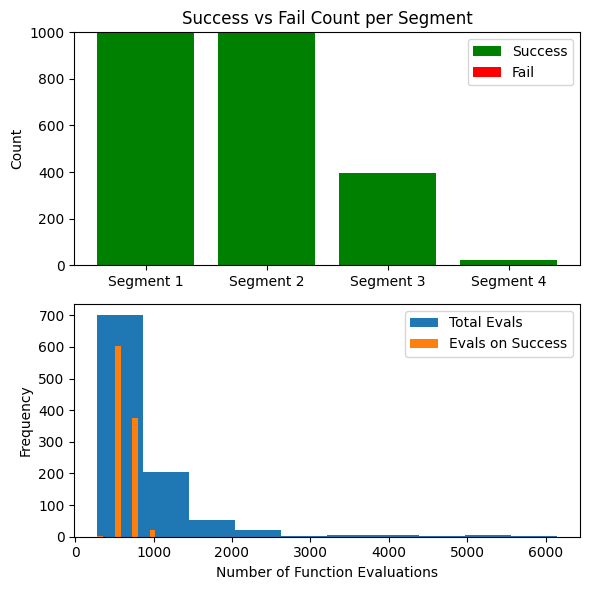

In [22]:
plot_histograms(result_list)

In [23]:
from qiskit.synthesis.two_qubit.xx_decompose import XXDecomposer

# strengths = {
#     1.5707963267948966: 1.01e-10,  # cx
#     0.7853981633974483: 5.1000000000000005e-11,  # cx2
#     0.5235987755982988: 3.433333333333333e-11,  # cx3
# }
basis_fidelities = {
    np.pi / 2: 1.0,  # cx
    np.pi / 4: 1.0,  # cx^(1/2)
    np.pi / 6: 1.0,  # cx^(1/3)
    # np.pi / 8: 1.0,  # cx^(1/4)
    # np.pi / 10: 1.0,  # cx^(1/5)
    # np.pi / 12: 1.0,  # cx^(1/6)
    # np.pi / 14: 1.0,  # cx^(1/7)
    # np.pi / 16: 1.0,  # cx^(1/8)
    # np.pi / 18: 1.0,  # cx^(1/9)
}

xx_durations = []
xx_decomposer = XXDecomposer(basis_fidelities)  # basis_fidelity=strengths)
for _ in tqdm(range(N)):
    start_time = time()
    target_gate = random_unitary(4).to_matrix()
    decomp = xx_decomposer(target_gate)
    xx_durations.append(time() - start_time)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [24]:
# from hetero_isas.sqrtiswap.siswap_decomposer import SiSwapDecomposer


# siswap_durations = []
# siswap_decomposer = SiSwapDecomposer(euler_basis="u")
# for _ in tqdm(range(N)):
#     start_time = time()
#     target_gate = random_unitary(4).to_matrix()
#     decomp = siswap_decomposer(target_gate)
#     siswap_durations.append(time() - start_time)

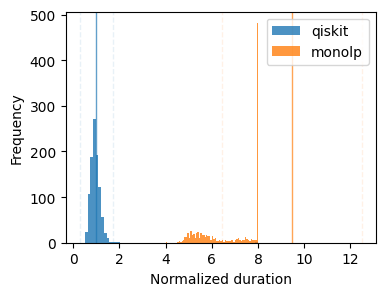

In [25]:
# duration historams
fig, ax = plt.subplots(1, 1, figsize=(4, 3))
bins = 64
amax = 8  # 0.05  # 0.08

cmap = plt.colormaps.get_cmap("tab10")

# histogram data and colors
data = [
    (xx_durations[1:], "qiskit"),
    (mono_durations[1:], "monolp"),  # (scipy)"),
    # (cplex_durations, "monolp(cplex)"),
]

normed_data = [
    (xx_durations / np.mean(xx_durations), "qiskit"),
    (mono_durations[1:] / np.mean(xx_durations), "monolp"),
]
for (durations, label), color in zip(normed_data, cmap.colors):
    clipped_data = np.clip(durations, a_min=0, a_max=amax)
    ax.hist(clipped_data, bins, label=label, alpha=0.8, color=color)
    mean = np.mean(durations)
    std = np.std(durations)

    ax.axvline(mean, color=color, linestyle="-", linewidth=1, alpha=0.7)
    ax.axvline(mean + std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)
    ax.axvline(mean - std / 2.0, color=color, linestyle="--", linewidth=1, alpha=0.1)

ax.set_ylabel("Frequency")
ax.set_xlabel("Normalized duration")
ax.legend()

In [26]:
fig.savefig("qiskitvsmonolp.svg", bbox_inches="tight")

In [27]:
%reload_ext snakeviz
import cProfile

cProfile.run(
    "decomposer(SwapGate())",
    "../../../docs/profile_timings/tempa.prof",
)

cProfile.run(
    "cplex_decomposer(SwapGate())",
    "../../../docs/profile_timings/tempb.prof",
)


def bench(X):
    for _ in range(X):
        target_gate = random_unitary(4).to_matrix()
        output_qc, lp_result = scipy_decomposer(target_gate, debugging=True)


cProfile.run(
    "bench(100)",
    "../../../docs/profile_timings/tempg.prof",
)

/home/evm9/hetero_isas/src/hetero_isas/monodromy_lp/invariants.py:94: UserWarning: Tried to recover local equivalence, but the c parameter had a sign difference.
  warnings.warn(


Tried to recover local equivalence on gates that were not locally equivalent.                 Often this is a matter of precision. The difference between expected and given                 weyl coords was [6.01963599e-06 3.96318655e-06 1.38845565e-05]. If this is close to 0, then adjust tolerances.
